### ETL & Feature Engineering for Retail Marketing Measurement

**Goal:**  
- Loading raw e-commerce event logs (RetailRocket data).  
- Creating:
  - Weekly sales time series  
  - Synthetic channel spend & promo controls  
  - Synthetic A/B test table  
  - Customer-level journeys for attribution  
- Saving these as Parquet ‘feature tables’ for downstream modeling.

This notebook represents the **ingestion / feature store** part of the pipeline.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EVENTS_PATH = Path("events.csv")  # your Kaggle file

### Now, we can define:
- `week_floor`: normalize timestamps to week-start
- `simulate_channel_spend`: stand-in for media spend logs
- small logger `_log`

In [22]:
def week_floor(ts):
    ts = pd.to_datetime(ts)
    return (ts - pd.to_timedelta(ts.dt.dayofweek, unit="D")).dt.normalize()

def simulate_channel_spend(weeks, channels=("search","social","email","display","direct")):
    rng = np.random.default_rng(42)
    spend = {}
    t = np.arange(len(weeks))
    for ch in channels:
        base = rng.uniform(5e3, 30e3)
        trend = rng.normal(0, 100, size=len(t)).cumsum()
        season = 3000*np.sin(2*np.pi*t/52 + rng.uniform(0, 2*np.pi))
        sat_bump = np.maximum(0, rng.normal(0, 2000, size=len(t)))
        spend[ch] = np.maximum(0, base + 0.1*trend + season + sat_bump)
    return (
        pd.DataFrame(spend, index=weeks)
          .rename_axis("week")
          .reset_index()
    )

def _log(msg):
    print(f"[ETL] {msg}")

### We use the RetailRocket clickstream dataset (public e-commerce data).  
Each row = a user (`visitorid`) doing an event (`view`, `addtocart`, or `transaction`) on an item at a timestamp in ms.

We'll:
1. Load the CSV
2. Convert timestamps to datetimes
3. Mark which rows correspond to purchases

In [23]:
if not EVENTS_PATH.exists():
    raise FileNotFoundError("File not found: events.csv")

_log("Reading RetailRocket-like events")
df = pd.read_csv(EVENTS_PATH)

# Convert timestamp ms -> datetime
df["ts"] = pd.to_datetime(df["timestamp"], unit="ms")

# Standardize IDs/outcomes
df["customer_id"] = df["visitorid"].astype(str)
df["is_purchase"] = df["event"].astype(str).str.contains(
    "transaction|purchase", case=False, regex=True
)

df.head()

[ETL] Reading RetailRocket-like events


,timestamp,visitorid,event,itemid,transactionid,ts,customer_id,is_purchase
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,257597,False
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,992329,False
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,111016,False
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,483717,False
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,951259,False


### Weekly sales

We'll define "weekly sales" as: number of purchase events per week  
(This is a simplification of revenue, good enough for MMM and promo analysis.)

We'll also build:
- A synthetic A/B experiment table
- Session paths per customer (for future Markov attribution)

In [24]:
# weekly sales
weekly_sales = (
    df[df["is_purchase"]]
      .assign(week=lambda d: week_floor(d["ts"]))
      .groupby("week", as_index=False)
      .agg(sales=("is_purchase", "size"))
)

# customer journeys (ordered event sequence)
sessions = (
    df.sort_values(["customer_id", "ts"])
      .groupby("customer_id")["event"]
      .apply(list)
      .reset_index()
      .rename(columns={"event": "path"})
)

# synthetic A/B experiment assignment
_log("Creating synthetic A/B treatment/control")
customers = df[["customer_id"]].drop_duplicates()
rng = np.random.default_rng(7)
customers["treatment"] = rng.integers(0, 2, size=len(customers))
cust_purchase = df.groupby("customer_id")["is_purchase"].max().reset_index()
ab = customers.merge(cust_purchase, on="customer_id", how="left").fillna(False)
ab = ab.rename(columns={"is_purchase": "converted"})

weekly_sales.head(), sessions.head(), ab.head()

[ETL] Creating synthetic A/B treatment/control


(        week  sales
 0 2015-04-27     83
 1 2015-05-04   1103
 2 2015-05-11   1218
 3 2015-05-18   1061
 4 2015-05-25   1146,
   customer_id                      path
 0           0        [view, view, view]
 1           1                    [view]
 2          10                    [view]
 3         100  [view, view, view, view]
 4        1000                    [view],
   customer_id  treatment  converted
 0      257597          1      False
 1      992329          1      False
 2      111016          1      False
 3      483717          1      False
 4      951259          1      False)

### ## Channel spend, promo flags, price index

Real retailers have:
- paid media spend by channel (search, social…)
- promo flags (yes/no)
- price index / price pressure

We don't have that in Kaggle, so we simulate *consistent, realistic-looking* weekly curves.

In [25]:
# Ensure full continuous weekly index
weeks_full = pd.date_range(weekly_sales["week"].min(),
                           weekly_sales["week"].max(),
                           freq="W-MON")
weekly_sales_full = (
    weekly_sales.set_index("week")
                .reindex(weeks_full)
                .fillna(method="ffill")
                .rename_axis("week")
                .reset_index()
)

_log("Simulating weekly channel spend time series.")
channel_spend = simulate_channel_spend(weeks_full)

_log("Creating control covariates (promo, price_index).")
rng_ctrl = np.random.default_rng(24)
controls = pd.DataFrame({
    "week": weeks_full,
    "price_index": 100
        + 2 * np.sin(2 * np.pi * np.arange(len(weeks_full)) / 26)
        + rng_ctrl.normal(0, 0.5, len(weeks_full)),
    "promo": (rng_ctrl.random(len(weeks_full)) < 0.2).astype(int),
})

features = (
    weekly_sales_full
      .merge(channel_spend, on="week")
      .merge(controls, on="week")
)

weekly_sales_full.head(), channel_spend.head(), features.head()

[ETL] Simulating weekly channel spend time series.
[ETL] Creating control covariates (promo, price_index).


C:\Users\91957\AppData\Local\Temp\ipykernel_14260\2610078475.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


(        week  sales
 0 2015-04-27     83
 1 2015-05-04   1103
 2 2015-05-11   1218
 3 2015-05-18   1061
 4 2015-05-25   1146,
         week        search        social         email       display  \
 0 2015-04-27  23789.287189  15266.425579  12104.222338  23274.454053   
 1 2015-05-04  24156.294785  17341.734672  11490.335828  26142.268279   
 2 2015-05-11  24527.969931  15965.130711  11305.326584  22723.271698   
 3 2015-05-18  25932.831159  16290.584648  11225.056484  24258.187978   
 4 2015-05-25  25938.070028  16586.831343  10826.644825  22090.847451   
 
          direct  
 0  26779.432416  
 1  27140.843275  
 2  28177.073739  
 3  30679.188502  
 4  28409.829142  ,
         week  sales        search        social         email       display  \
 0 2015-04-27     83  23789.287189  15266.425579  12104.222338  23274.454053   
 1 2015-05-04   1103  24156.294785  17341.734672  11490.335828  26142.268279   
 2 2015-05-11   1218  24527.969931  15965.130711  11305.326584  22723.271698  

### Persisting feature tables

Downstream models will read these directly instead of recomputing ETL.
This is similar to how a measurement team would publish model-ready tables to analysts / services.


In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

weekly_sales_full.to_parquet(OUTPUT_DIR / "weekly_sales.parquet", index=False)
channel_spend.to_parquet(OUTPUT_DIR / "channel_spend.parquet", index=False)
features.to_parquet( OUTPUT_DIR / "features.parquet", index=False)
sessions.to_parquet( OUTPUT_DIR / "sessions.parquet", index=False)
ab.to_parquet(       OUTPUT_DIR / "ab_experiment.parquet", index=False)

_log(f"Wrote outputs to {OUTPUT_DIR.resolve()}")

[ETL] Wrote outputs to C:\Users\91957\Desktop\MS Admissions\Concordia University\MachineLearningProjects\RetailMarkovChain\retail-measurement-lab\etl\data\outputs


### We'll quickly visualize sales over time to confirm we actually have signal.

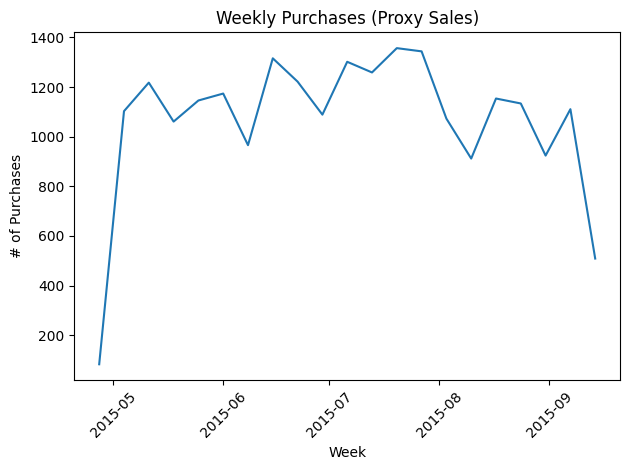

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(weekly_sales_full["week"], weekly_sales_full["sales"])
plt.title("Weekly Purchases (Proxy Sales)")
plt.xlabel("Week")
plt.ylabel("# of Purchases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()